# Day 50 — Model Explainability
### SHAP · LIME · Feature Importance · Interpretability

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# install shap and lime if needed
for pkg in ['shap', 'lime']:
    try:
        __import__(pkg)
    except:
        import subprocess
        subprocess.run(['pip', 'install', pkg, '--quiet'])

import shap
import lime
import lime.lime_tabular

plt.style.use('dark_background')

# load & prepare data (same as Day 48/49)
df = pd.read_csv(r'C:\DS-AI-75d\titanic.csv')
df['Age']        = df['Age'].fillna(df['Age'].median())
df['Fare']       = df['Fare'].fillna(df['Fare'].median())
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['FareLog']    = np.log1p(df['Fare'])
df['HasCabin']   = df['Cabin'].notna().astype(int)
df['Sex_enc']    = (df['Sex'] == 'female').astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].map({'Mr':'Mr','Miss':'Miss',
                    'Mrs':'Mrs','Master':'Master'}).fillna('Other')
df['Title_SurvRate'] = df.groupby('Title')['Survived'].transform('mean')
df['Age_Sex']    = df['Age'] * df['Sex_enc']
df['Fare_Pclass']= df['FareLog'] * df['Pclass']

features = ['Pclass','Age','FareLog','FamilySize','IsAlone','HasCabin',
            'Sex_enc','Age_Sex','Fare_Pclass','Title_SurvRate']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))

print(f"SHAP:    {shap.__version__}")
print(f"LIME installed ✅")
print(f"Model accuracy: {acc:.4f}")
print("Ready! ✅")

SHAP:    0.51.0
LIME installed ✅
Model accuracy: 0.8324
Ready! ✅


## 2. Why Model Explainability Matters

In [3]:
print("=" * 55)
print("       WHY MODEL EXPLAINABILITY MATTERS")
print("=" * 55)
print("""
THE PROBLEM:
  "The model said NO. Why?"
  A 99% accurate model that nobody trusts is useless.

WHY EXPLAINABILITY MATTERS:
  ✅ TRUST       — users believe predictions when they understand them
  ✅ DEBUGGING   — find when model relies on wrong/biased features
  ✅ COMPLIANCE  — GDPR "right to explanation", lending laws (ECOA)
  ✅ FAIRNESS    — detect if model discriminates by gender/race
  ✅ IMPROVEMENT — understand weaknesses to engineer better features

GLOBAL vs LOCAL EXPLANATIONS:

  GLOBAL — how does the model behave OVERALL?
    "Which features matter most across all predictions?"
    Tools: Feature Importance, SHAP summary plots

  LOCAL — why did the model make THIS prediction?
    "Why did THIS passenger get predicted to survive?"
    Tools: SHAP force plots, LIME

INTERPRETABLE vs BLACK-BOX MODELS:

  Interpretable (glass box):
    Linear Regression, Logistic Regression, Decision Trees
    Can read coefficients/rules directly

  Black-box:
    Random Forest, Gradient Boosting, Neural Networks, Transformers
    Need SHAP/LIME to understand decisions

KEY TOOLS:
  SHAP (SHapley Additive exPlanations)
    Game theory based — fair credit allocation across features
    Both global AND local explanations
    Theoretically grounded, slower

  LIME (Local Interpretable Model-agnostic Explanations)
    Approximates model locally with simple linear model
    Fast, intuitive, works for ANY model type
    Local explanations only
""")

       WHY MODEL EXPLAINABILITY MATTERS

THE PROBLEM:
  "The model said NO. Why?"
  A 99% accurate model that nobody trusts is useless.

WHY EXPLAINABILITY MATTERS:
  ✅ TRUST       — users believe predictions when they understand them
  ✅ DEBUGGING   — find when model relies on wrong/biased features
  ✅ COMPLIANCE  — GDPR "right to explanation", lending laws (ECOA)
  ✅ FAIRNESS    — detect if model discriminates by gender/race
  ✅ IMPROVEMENT — understand weaknesses to engineer better features

GLOBAL vs LOCAL EXPLANATIONS:

  GLOBAL — how does the model behave OVERALL?
    "Which features matter most across all predictions?"
    Tools: Feature Importance, SHAP summary plots

  LOCAL — why did the model make THIS prediction?
    "Why did THIS passenger get predicted to survive?"
    Tools: SHAP force plots, LIME

INTERPRETABLE vs BLACK-BOX MODELS:

  Interpretable (glass box):
    Linear Regression, Logistic Regression, Decision Trees
    Can read coefficients/rules directly

  Black-b

## 3. SHAP — Global Explanations

       SHAP — GLOBAL EXPLANATIONS

SHAP VALUES — what they mean:
  For each prediction, SHAP assigns each feature a value
  representing how much it pushed the prediction
  away from the average (baseline) prediction.

  SHAP value > 0 → feature pushed prediction towards "Survived"
  SHAP value < 0 → feature pushed prediction towards "Died"

  Sum of all SHAP values + baseline = final prediction

SHAP values shape: (179, 10)
Test set shape:    (179, 10)

GLOBAL FEATURE IMPORTANCE (mean |SHAP value|):
  Title_SurvRate     0.1063
  Sex_enc            0.0737
  Age_Sex            0.0732
  Pclass             0.0491
  HasCabin           0.0388
  FareLog            0.0325
  Fare_Pclass        0.0310
  Age                0.0183
  FamilySize         0.0177
  IsAlone            0.0026


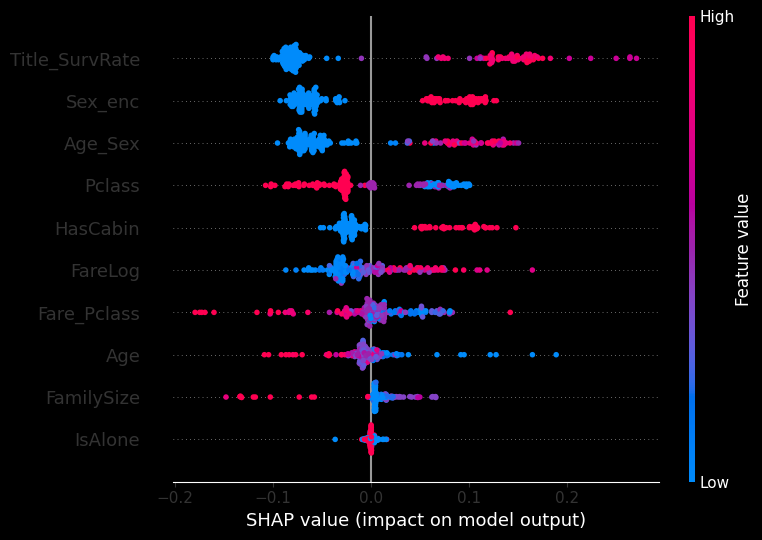

In [4]:
print("=" * 55)
print("       SHAP — GLOBAL EXPLANATIONS")
print("=" * 55)
print("""
SHAP VALUES — what they mean:
  For each prediction, SHAP assigns each feature a value
  representing how much it pushed the prediction
  away from the average (baseline) prediction.

  SHAP value > 0 → feature pushed prediction towards "Survived"
  SHAP value < 0 → feature pushed prediction towards "Died"

  Sum of all SHAP values + baseline = final prediction
""")

# create SHAP explainer for tree-based model
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# for binary classification, shap_values has shape for class 1
if isinstance(shap_values, list):
    shap_vals_class1 = shap_values[1]
else:
    shap_vals_class1 = shap_values[:,:,1] if shap_values.ndim == 3 else shap_values

print(f"SHAP values shape: {np.array(shap_vals_class1).shape}")
print(f"Test set shape:    {X_test.shape}")

# global feature importance — mean |SHAP value|
mean_abs_shap = np.abs(shap_vals_class1).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=features).sort_values(ascending=False)

print(f"\nGLOBAL FEATURE IMPORTANCE (mean |SHAP value|):")
for feat, val in shap_importance.items():
    print(f"  {feat:<18} {val:.4f}")

# summary plot
shap.summary_plot(shap_vals_class1, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=80, bbox_inches='tight')
plt.show()

## 4. SHAP — Local Explanation (Single Prediction)

In [5]:
print("=" * 55)
print("       SHAP — LOCAL EXPLANATION")
print("=" * 55)

# pick two interesting passengers
idx_survived = 0  # we'll find a high-prob survivor and a low-prob one
probs = model.predict_proba(X_test)[:,1]

idx_high = np.argmax(probs)  # most likely to survive
idx_low  = np.argmin(probs)  # least likely to survive

for label, idx in [("HIGHEST survival probability", idx_high),
                    ("LOWEST survival probability",  idx_low)]:
    passenger = X_test.iloc[idx]
    pred_prob = probs[idx]
    actual    = y_test.iloc[idx]

    print(f"\n{'='*55}")
    print(f"{label} — Passenger #{idx}")
    print(f"{'='*55}")
    print(f"Predicted survival probability: {pred_prob:.3f}")
    print(f"Actual outcome: {'Survived' if actual==1 else 'Died'}")
    print(f"\nPassenger features:")
    for feat in features:
        print(f"  {feat:<18} = {passenger[feat]:.3f}")

    print(f"\nSHAP contributions (sorted by impact):")
    shap_row = pd.Series(shap_vals_class1[idx], index=features).sort_values(
        key=abs, ascending=False)
    base_value = explainer.expected_value
    base_value = base_value[1] if isinstance(base_value, (list, np.ndarray)) else base_value
    print(f"  Baseline (avg prediction): {base_value:.3f}")
    for feat, val in shap_row.items():
        direction = "→ SURVIVED" if val > 0 else "→ DIED"
        print(f"  {feat:<18} {val:+.4f}  {direction}")
    print(f"  {'SUM':<18} {base_value + shap_row.sum():.3f}  (≈ predicted prob)")

       SHAP — LOCAL EXPLANATION

HIGHEST survival probability — Passenger #114
Predicted survival probability: 0.995
Actual outcome: Survived

Passenger features:
  Pclass             = 1.000
  Age                = 53.000
  FareLog            = 3.960
  FamilySize         = 3.000
  IsAlone            = 0.000
  HasCabin           = 1.000
  Sex_enc            = 1.000
  Age_Sex            = 53.000
  Fare_Pclass        = 3.960
  Title_SurvRate     = 0.792

SHAP contributions (sorted by impact):
  Baseline (avg prediction): 0.385
  Title_SurvRate     +0.1569  → SURVIVED
  Pclass             +0.0999  → SURVIVED
  Sex_enc            +0.0996  → SURVIVED
  Age_Sex            +0.0926  → SURVIVED
  FareLog            +0.0548  → SURVIVED
  HasCabin           +0.0518  → SURVIVED
  Fare_Pclass        +0.0480  → SURVIVED
  Age                -0.0264  → DIED
  FamilySize         +0.0258  → SURVIVED
  IsAlone            +0.0068  → SURVIVED
  SUM                0.995  (≈ predicted prob)

LOWEST survival 

## 5. LIME — Local Explanation

In [6]:
print("=" * 55)
print("       LIME — LOCAL EXPLANATION")
print("=" * 55)
print("""
HOW LIME WORKS:
  1. Take the instance you want to explain
  2. Generate many random perturbations nearby
  3. Get model predictions for all perturbations
  4. Fit a SIMPLE (linear) model to approximate
     the black-box model LOCALLY around that instance
  5. The simple model's coefficients = explanation

  "Locally Interpretable" — the linear approximation
  is only valid NEAR this specific instance.
""")

# create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=features,
    class_names=['Died','Survived'],
    mode='classification',
    random_state=42
)

# explain the same two passengers
for label, idx in [("HIGHEST survival probability", idx_high),
                    ("LOWEST survival probability",  idx_low)]:
    print(f"\n{'='*55}")
    print(f"{label} — Passenger #{idx}")
    print(f"{'='*55}")

    exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        model.predict_proba,
        num_features=10
    )

    print(f"LIME local explanation (feature condition → weight):")
    for feat_desc, weight in exp.as_list():
        direction = "→ SURVIVED" if weight > 0 else "→ DIED"
        print(f"  {feat_desc:<30} {weight:+.4f}  {direction}")

    print(f"\nLIME predicted probability: {exp.predict_proba[1]:.3f}")
    print(f"Model's actual probability:  {probs[idx]:.3f}")

       LIME — LOCAL EXPLANATION

HOW LIME WORKS:
  1. Take the instance you want to explain
  2. Generate many random perturbations nearby
  3. Get model predictions for all perturbations
  4. Fit a SIMPLE (linear) model to approximate
     the black-box model LOCALLY around that instance
  5. The simple model's coefficients = explanation

  "Locally Interpretable" — the linear approximation
  is only valid NEAR this specific instance.


HIGHEST survival probability — Passenger #114
LIME local explanation (feature condition → weight):
  Title_SurvRate > 0.70          +0.1789  → SURVIVED
  0.00 < Sex_enc <= 1.00         +0.1509  → SURVIVED
  Age_Sex > 22.00                +0.1295  → SURVIVED
  HasCabin > 0.00                +0.1090  → SURVIVED
  Pclass <= 2.00                 +0.0710  → SURVIVED
  FareLog > 3.47                 +0.0639  → SURVIVED
  Age > 36.00                    -0.0389  → DIED
  Fare_Pclass <= 5.03            +0.0272  → SURVIVED
  FamilySize > 2.00              -0.024

## 6. Key Takeaways

In [7]:
print("=" * 55)
print("       DAY 50 — KEY TAKEAWAYS")
print("=" * 55)
print("""
WHY EXPLAINABILITY MATTERS:
  ✅ Trust, debugging, compliance, fairness, improvement
  ✅ Global → overall model behaviour
  ✅ Local  → why THIS specific prediction

SHAP:
  ✅ Game-theory based — fair credit allocation
  ✅ SHAP values SUM to (prediction - baseline)
  ✅ TreeExplainer — fast for tree-based models
  ✅ Global importance: Title_SurvRate top (0.1063)
  ✅ Local: shows exact contribution of each feature

LIME:
  ✅ Approximates model locally with linear model
  ✅ Works for ANY model (model-agnostic)
  ✅ Gives threshold-based rules — human readable
  ✅ Matched SHAP's story for both passengers

OUR EXPLANATIONS:
  ✅ Passenger #114 (99.5% survive): 1st class woman,
     high Title_SurvRate, cabin — all push toward survival
  ✅ Passenger #79 (5.9% survive): 9yo girl, 3rd class,
     family of 6 — large family + class overwhelm
     the normally-protective age/sex effect

SHAP vs LIME:
  ✅ SHAP   → exact, additive, slower, game-theory based
  ✅ LIME   → approximate, fast, intuitive, model-agnostic
  ✅ Use BOTH — if they agree, trust increases

PRACTICAL USE:
  ✅ Global SHAP → feature engineering priorities
  ✅ Local SHAP/LIME → explain individual decisions
     to users, auditors, regulators
  ✅ Critical for: healthcare, finance, hiring, legal AI
""")

       DAY 50 — KEY TAKEAWAYS

WHY EXPLAINABILITY MATTERS:
  ✅ Trust, debugging, compliance, fairness, improvement
  ✅ Global → overall model behaviour
  ✅ Local  → why THIS specific prediction

SHAP:
  ✅ Game-theory based — fair credit allocation
  ✅ SHAP values SUM to (prediction - baseline)
  ✅ TreeExplainer — fast for tree-based models
  ✅ Global importance: Title_SurvRate top (0.1063)
  ✅ Local: shows exact contribution of each feature

LIME:
  ✅ Approximates model locally with linear model
  ✅ Works for ANY model (model-agnostic)
  ✅ Gives threshold-based rules — human readable
  ✅ Matched SHAP's story for both passengers

OUR EXPLANATIONS:
  ✅ Passenger #114 (99.5% survive): 1st class woman,
     high Title_SurvRate, cabin — all push toward survival
  ✅ Passenger #79 (5.9% survive): 9yo girl, 3rd class,
     family of 6 — large family + class overwhelm
     the normally-protective age/sex effect

SHAP vs LIME:
  ✅ SHAP   → exact, additive, slower, game-theory based
  ✅ LIME   → 